## **INDRODUCTION**


In this Project we examined a dataset created in order to assist research directed toward decreasing dropout and failure in higher education. The dataset encompasses information available at the time of enrollment, including information about students' academic history, demographic information, and relevant socio-economic information. We specifically aim to examine the data distribution and characteristics that drive academic outcomes (dropout, enrolled, or graduate).
We employed a variety of exploratory data analysis (EDA) techniques, including the generation of histograms to illustrate data distributions, and calculating descriptive statistics such as mean, median, mode, standard deviation, variance, and covariance. Additionally, we created boxplots to examine outliers as well as illustrating the dispersion of different variable data. Together, this analysis provides context to the data structure and may assist in identifying characteristics that can later be employed in predictive modeling with machine learning.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)

# data (as pandas dataframes)
X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets

# metadata
print(predict_students_dropout_and_academic_success.metadata)

# variable information
print(predict_students_dropout_and_academic_success.variables)


{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

# **DISTRIBUTION OF STUDENT FEATURES**
Histograms visualize how each feature (such as marital status ,application mode,applicaytion order,distribution of course, etc.) is distributed across the dataset. They show the frequency of values and highlight whether the data is skewed, uniform, or normally distributed.



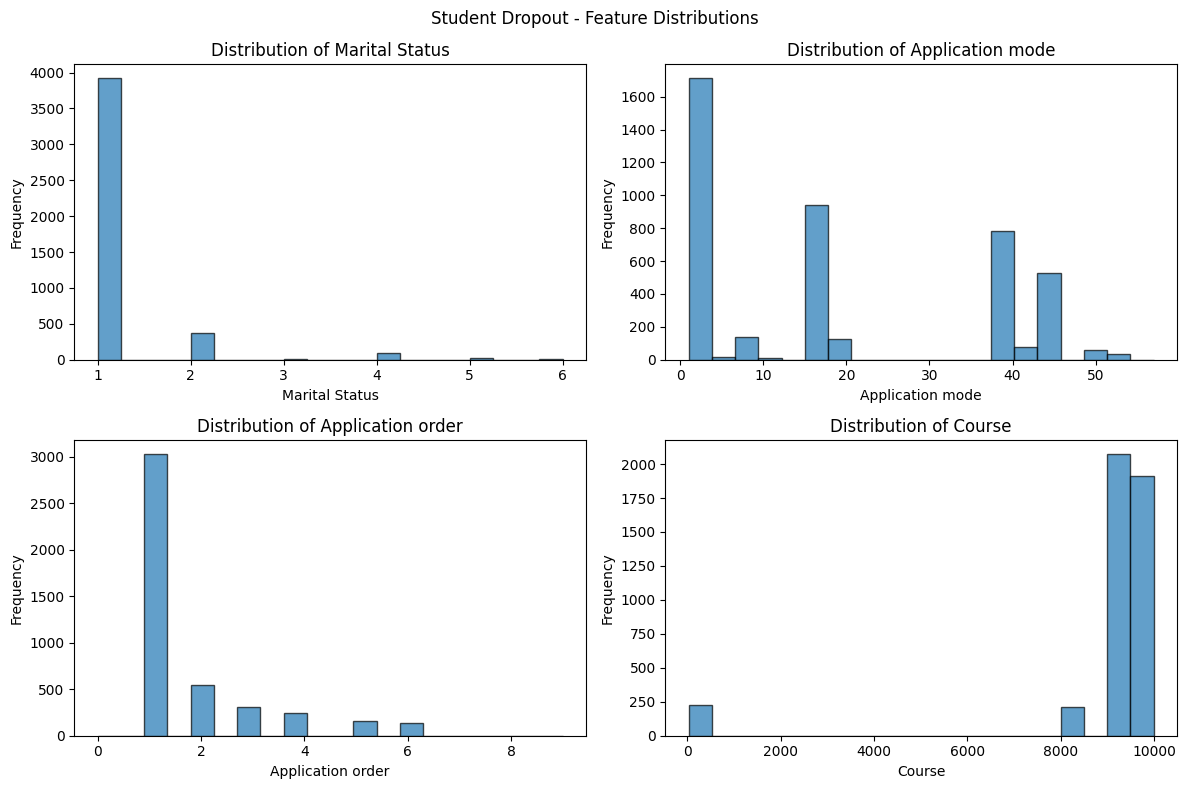

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Student Dropout - Feature Distributions")

features_to_plot = X.columns[:4]

for i, col in enumerate(features_to_plot):
    ax = axes[i//2, i%2]
    ax.hist(X[col], bins=20, alpha=0.7, edgecolor='black')
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# **Kernel-Density Estimation**
Kernel - Density estimation is a simple way to estimate the probability Density Function of a dataset.It makes a smooth curve showing the distribution of data points, helping to visualize patterns and understand how the values are concentrated or spread out.It is particularly used for identifying peaks, asymmetry, and the overall shape of data distribution.

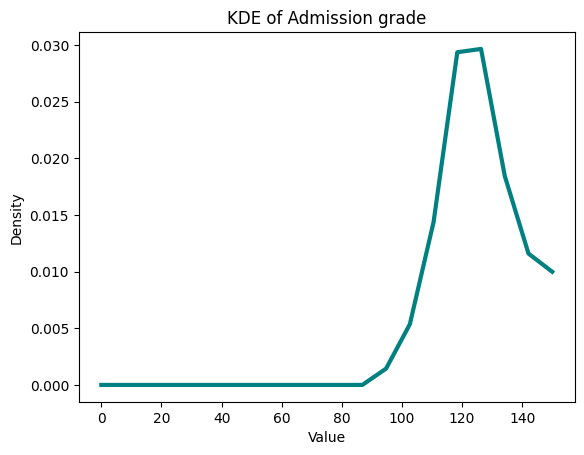

In [ ]:
from scipy.stats import gaussian_kde

kde = gaussian_kde(X['Admission grade'], bw_method=0.1)  # smaller bw = more detailed

# Evaluate KDE on a grid
x = np.linspace(0, 150, 20)
y = kde(x)

# Plot
plt.plot(x, y, color='teal', lw = 3)
plt.title("KDE of Admission grade")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

# **MEAN VALUE OF STUDENT FEATURES**
The notebook calculates the average value of each student feature, summarizing the central tendency of the dataset. It helps understand the overall performance and common behavior across features.


In [ ]:
mean_students = np.mean(X)
print('The mean is: ', mean_students)

The mean is:  258.5455723500973


# **MEDIAN AND MODE VALUES OF STUDENT FEATURES**
The median represents the middle point of each feature’s distribution, providing a more robust measure of central tendency that isn’t affected by extreme outliers or skewed data.

The mode identifies the most frequently occurring value in each feature. It highlights the most common behavior or category among students in the dataset.

In [ ]:
median_students = np.median(X)
print('The mean is: ', mean_students)

from scipy.stats import mode
mode_students = mode(X)
print('The mode is: ', mode_students[0])

The mean is:  258.5455723500973
The mode is:  [1.000e+00 1.000e+00 1.000e+00 9.500e+03 1.000e+00 1.000e+00 1.331e+02
 1.000e+00 1.000e+00 3.700e+01 9.000e+00 9.000e+00 1.300e+02 1.000e+00
 0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00 1.800e+01 0.000e+00
 0.000e+00 6.000e+00 8.000e+00 6.000e+00 0.000e+00 0.000e+00 0.000e+00
 6.000e+00 8.000e+00 6.000e+00 0.000e+00 0.000e+00 7.600e+00 1.400e+00
 3.200e-01]


# **STANDARD DEVIATION OF STUDENT FEATURES**
The standard deviation provides an interpretable measure of spread, showing how much each feature’s values deviate from the mean on average. It helps assess variability in student data

In [ ]:
print("\nStandard Deviation for each feature:")
std_dev = X.std()
print(std_dev)


Standard Deviation for each feature:
Marital Status                                       0.605747
Application mode                                    17.484682
Application order                                    1.313793
Course                                            2063.566416
Daytime/evening attendance                           0.311897
Previous qualification                              10.216592
Previous qualification (grade)                      13.188332
Nacionality                                          6.914514
Mother's qualification                              15.603186
Father's qualification                              15.343108
Mother's occupation                                 26.418253
Father's occupation                                 25.263040
Admission grade                                     14.482001
Displaced                                            0.497711
Educational special needs                            0.106760
Debtor                          

# **VARIANCE OF STUDENT FEATURES**
The variance provides how far data points are spread from mean.The variance calculates the degree to which the values of each feature deviate from the mean. It is computed by taking the average of the squared deviations from the mean. While a lower variance indicates that values are closer to the mean, a higher variance indicates that the data points are more widely distributed.



In [ ]:
print("\nVariance for each feature:")
variance = X.var()
print(variance)


Variance for each feature:
Marital Status                                    3.669294e-01
Application mode                                  3.057141e+02
Application order                                 1.726052e+00
Course                                            4.258306e+06
Daytime/evening attendance                        9.727954e-02
Previous qualification                            1.043788e+02
Previous qualification (grade)                    1.739321e+02
Nacionality                                       4.781050e+01
Mother's qualification                            2.434594e+02
Father's qualification                            2.354110e+02
Mother's occupation                               6.979241e+02
Father's occupation                               6.382212e+02
Admission grade                                   2.097283e+02
Displaced                                         2.477161e-01
Educational special needs                         1.139771e-02
Debtor                     

# **COVARIANCE OF STUDENT FEATURES**
Covariance shows the combined variation of two features. A negative covariance indicates that when one feature rises, the other tends to fall, whereas a positive covariance indicates that when one feature rises, the other tends to rise as well. It facilitates comprehension of the connections between student feature pairs.

In [ ]:
print("\nCovariance Matrix:")
cov_matrix = X.cov()
print(cov_matrix)


Covariance Matrix:
                                                Marital Status  \
Marital Status                                        0.366929   
Application mode                                      2.796163   
Application order                                    -0.100158   
Course                                               57.956437   
Daytime/evening attendance                           -0.051944   
Previous qualification                                0.386971   
Previous qualification (grade)                       -0.179000   
Nacionality                                          -0.037039   
Mother's qualification                                1.825700   
Father's qualification                                1.211508   
Mother's occupation                                   0.560003   
Father's occupation                                   0.483713   
Admission grade                                      -0.041853   
Displaced                                            -0.

# **BOXPLOTS OF STUDENT FEATURES**
Five essential summary statistics—the minimum, first quartile (Q1), median, third quartile (Q3), and maximum—are used in a boxplot to graphically depict the distribution of data. It is helpful for comparing distributions across several features because it draws attention to the spread, central tendency, and possible outliers in student feature data.

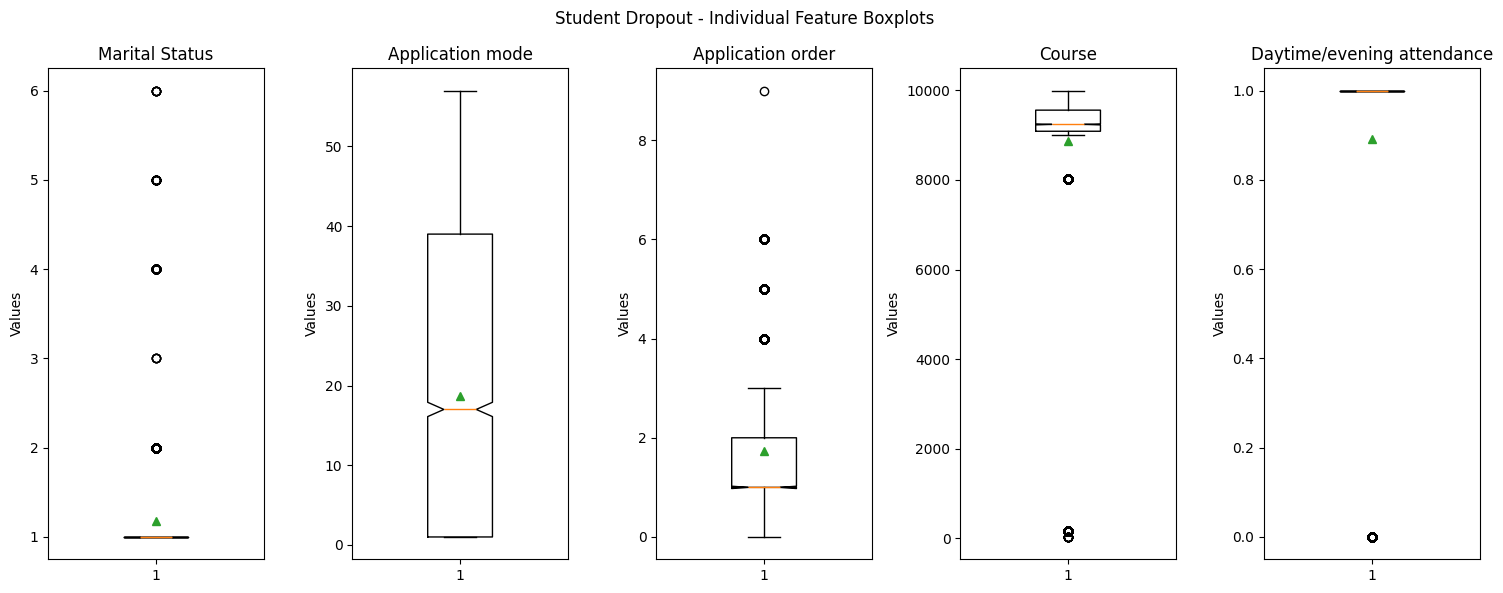

In [ ]:
import matplotlib.pyplot as plt

selected_features = X.columns[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 6))
fig.suptitle("Student Dropout - Individual Feature Boxplots")

for i, col in enumerate(selected_features):
    axes[i].boxplot(X[col], notch=True, showmeans=True, widths=0.3)
    axes[i].set_title(col)
    axes[i].set_ylabel("Values")

plt.tight_layout()
plt.show()

## **CONCLUSION**
In this Project we analyzed a dataset that was created to support research aiming at the reduction of dropout and failure rates in tertiary education. The dataset includes information that was accessible at the time of enrollment, which consists of students' academic records, demographic data, and socioeconomic factors. We have a specific interest in the data distribution and characteristics that influence academic outcomes (dropout, enrolled, or graduate) examination. We have utilized various EDA techniques for exploratory data analysis, such as the creation of histograms to visualize data distributions and computing descriptive statistics like mean, median, mode, standard deviation, variance, and covariance. Moreover, we made use of boxplots to identify outliers and to visualize the spread of different variable data at the same time. This combined analysis not only sheds light on the structure of the data, but also helps in the detection of the characteristics which can be later used for the purpose of predictive modeling through the use of machine learning.